In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm import tqdm
import json, os, gc
from datasets import load_dataset
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils

# ====================== CONFIG ======================
MODEL_NAME = "Qwen/Qwen3-4B"
DEVICE = "cuda"
BATCH_SIZE = 8          # Very conservative for 8B
EPOCHS = 8
LR = 5e-4

ACTIVATION_TYPES = ["resid_post", "mlp_post", "attn_out"]  # Add more as needed
LAYER_PERCENTAGES = [
    0.4, 0.5, 0.6, 0.8, 0.9, 
                    #  1.0
                     ]

SAVE_DIR = "./harmfulness_activations_qwen3"
os.makedirs(SAVE_DIR, exist_ok=True)

In [42]:
N_SAMPLES = 4000

In [ ]:
# ====================== BETTER MATCHED DATASETS ======================
print("Loading matched harmful/benign dataset...")

# Option 1: ToxiGen (recommended - implicit toxic vs benign, same style)
ds = load_dataset("toxigen/toxigen-data", "train", split="train")

# Filter to get balanced harmful/benign
harmful_texts = set()
benign_texts = set()

for ex in ds:
    if len(harmful_texts) >= N_SAMPLES and len(benign_texts) >= N_SAMPLES:
        break
    text = ex["text"] if "text" in ex else ex.get("prompt", ex.get("sentence", ""))
    if ex.get("toxicity", ex.get("toxic", 0)) > 0.5 or ex.get("prompt_label", 0) == 1:
        if len(harmful_texts) < N_SAMPLES:
            harmful_texts.add(text)
    else:
        if len(benign_texts) < N_SAMPLES:
            benign_texts.add(text)

print(f"Loaded {len(harmful_texts)} harmful + {len(benign_texts)} benign from ToxiGen")

# Option 2: Alternative if ToxiGen fails (WMDP-focused)
# from datasets import load_dataset
# harmful_ds = load_dataset("cais/wmdp", "wmdp_bio", split="test")
# harmful_texts = [ex["question"] for ex in harmful_ds.select(range(1100))]
# 
# # Use a benign biology dataset
# benign_ds = load_dataset("boyiwei/BenignBio", split="train")  # exists per search
# benign_texts = [ex["question"] for ex in benign_ds.select(range(1100))]

all_texts = list(harmful_texts) + list(benign_texts)
all_labels = [1] * len(harmful_texts) + [0] * len(benign_texts)

Loading matched harmful/benign dataset...


ValueError: Unknown split "test". Should be one of ['train'].

In [ ]:
# ------------------ 2. LOAD MODEL ------------------
print("Loading Qwen3-4B...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    # fold_ln=True,
    # center_writing_weights=True,
    # center_unembed=True,
    dtype=torch.bfloat16,
    trust_remote_code=True,   # important for Qwen
)

print(f"Loaded model with {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")

Loading Qwen3-4B...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Loaded model with 36 layers, d_model=2560


In [7]:
# ------------------ 3. LINEAR PROBE ------------------
class LinearProbe(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [45]:
# ====================== SAVE ACTIVATIONS PER BATCH ======================
def save_activations(texts, labels, split_name="all"):
    """Save activations batch-by-batch to avoid OOM"""
    # tokenizer = model.tokenizer
    for act_type in ACTIVATION_TYPES:
        for rel_p in LAYER_PERCENTAGES:
            layer_idx = int(rel_p * model.cfg.n_layers)
            act_dir = f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split_name}"
            os.makedirs(act_dir, exist_ok=True)
            
            for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=f"{act_type} L{layer_idx} {split_name}"):
                batch_texts = texts[i:i+BATCH_SIZE]
                batch_labels = labels[i:i+BATCH_SIZE]
                
                # tokens = tokenizer(batch_texts, padding=True, truncation=True,
                #                  max_length=1024, return_tensors="pt").input_ids.to(DEVICE)
                
                tokens = model.to_tokens(batch_texts)
                with torch.no_grad():
                    _, cache = model.run_with_cache(
                        tokens,
                        names_filter=lambda n: n == utils.get_act_name(act_type, layer_idx),
                        return_type=None
                    )
                    
                    act = cache[utils.get_act_name(act_type, layer_idx)]  # (batch, seq, d)
                    pooled = act.mean(dim=1).cpu()  # or act[:, -1, :] for last token
                    
                    # Save batch
                    torch.save({
                        "activations": pooled,
                        "labels": torch.tensor(batch_labels, dtype=torch.float32)
                    }, f"{act_dir}/batch_{i//BATCH_SIZE:06d}.pt")
                    
                    del cache, act, pooled
                    gc.collect()
                    torch.cuda.empty_cache()

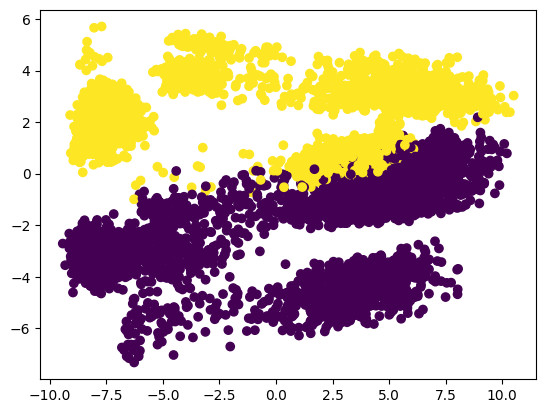

In [46]:
save_activations(all_texts, all_labels)

attn_out L32 all: 100%|██████████| 1000/1000 [05:32<00:00,  3.01it/s]


In [48]:
def gather_full_tensor( act_type, layer_idx, split='all'):
    files = sorted([
            f for f in os.listdir(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}")
            if f.endswith(".pt")
     ])
    activations = []
    labels = []
    for file in files:
        f = torch.load(f"{SAVE_DIR}/{act_type}_layer{layer_idx}_{split}/{file}")
        activations.append(f['activations'])
        labels.append(f['labels'])
    activations = torch.cat(
        activations, dim=0
    )
    labels = torch.cat(labels, dim=0)
    return activations, labels

In [49]:
# ====================== LOAD DATASET FROM DISK ======================
class ActivationDataset(torch.utils.data.Dataset):
    def __init__(self, act_type, layer_idx, split="train"):
        self.data, self.labels = gather_full_tensor(act_type, layer_idx, split)

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        data = self.data[idx]
        return data, self.labels[idx]

In [50]:
train_ds.dataset.labels.sum()

tensor(550.)

In [51]:
full_dataset.labels[train_ds.indices].sum()

tensor(440.)

In [64]:
from sklearn.linear_model import LogisticRegression 

lr = LogisticRegression()

xtr = full_dataset.data.to(float)[train_ds.indices].numpy()
ytr = full_dataset.labels.to(float)[train_ds.indices].numpy()

In [65]:
lr.fit(xtr, ytr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
xte = full_dataset.data.to(float)[val_ds.indices].numpy()
yte = full_dataset.labels.to(float)[val_ds.indices].numpy()

preds = lr.predict(
xte
)

In [69]:
yte[:20] 

array([0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 0., 1.])

In [67]:
from sklearn.metrics import accuracy_score 

accuracy_score(yte, preds)

1.0

In [58]:
EPOCHS = 1

In [61]:
# ====================== TRAINING ======================
results = {}

for act_type in ACTIVATION_TYPES:
    for rel_p in LAYER_PERCENTAGES:
        layer_idx = int(rel_p * model.cfg.n_layers)
        print(f"\n=== Training probe: {act_type} @ layer {layer_idx} ({rel_p*100:.0f}%) ===")
        
        generator = torch.Generator().manual_seed(42)
        full_dataset =  ActivationDataset(act_type, layer_idx, 'all')
        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset, lengths=[0.8, 0.2],
            generator=generator
        )
        
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)
        
        probe = nn.Sequential(
            nn.Linear(full_dataset.data[0].size(-1), 1),
            nn.Sigmoid()
        ).to(DEVICE)
        
        optimizer = optim.AdamW(probe.parameters(), lr=LR, weight_decay=1e-1)
        criterion = nn.BCELoss()
        
        # Training loop (same as before - abbreviated)
        best_auc = 0
        best_val_auc = 0
        best_state = None
        
        for epoch in range(EPOCHS):
            probe.train()
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(DEVICE).to(torch.float32), yb.squeeze().to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(probe(Xb).squeeze(), yb)
                loss.backward()
                optimizer.step()
            
            # Validation
            probe.eval()
            val_preds, val_true = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb = Xb.to(torch.float32).to(DEVICE)
                    preds = probe(Xb).cpu().squeeze().numpy()
                    val_preds.extend(preds)
                    val_true.extend(yb.numpy().squeeze())
            
            val_preds = np.array(val_preds)
            val_true = np.array(val_true)
            val_acc = accuracy_score(val_true, val_preds > 0.5)
            val_auc = roc_auc_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds > 0.5)
            
            print(f"Epoch {epoch+1:2d} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")
            
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
    
            # Save
            probe.load_state_dict(best_state)
            torch.save(best_state, f"{SAVE_DIR}/probe_l{layer_idx}_{act_type}.pt")
            
            results[layer_idx] = {"acc": val_acc, "auc": best_val_auc, "f1": val_f1}
        

print("Done. Results saved.")


=== Training probe: resid_post @ layer 14 (40%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: resid_post @ layer 18 (50%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: resid_post @ layer 21 (60%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: resid_post @ layer 28 (80%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: resid_post @ layer 32 (90%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: mlp_post @ layer 14 (40%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: mlp_post @ layer 18 (50%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: mlp_post @ layer 21 (60%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: mlp_post @ layer 28 (80%) ===
Epoch  1 | Acc: 1.0000 | AUC: 1.0000 | F1: 1.0000

=== Training probe: mlp_post @ layer 32 (90%) ===
Epoch  1 | Acc: 1.0000 | AUC: 

In [57]:
probe[0].weight.min()

tensor(-0.0685, device='cuda:0', grad_fn=<MinBackward1>)

In [47]:
import matplotlib.pyplot as plt 

plt.hist(probe[0].weight.numpy())

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

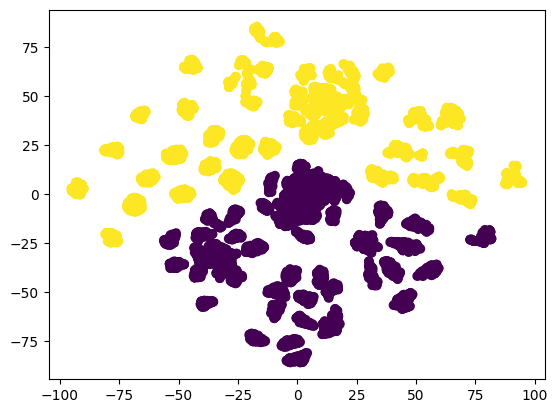

In [83]:
from sklearn.decomposition import PCA  
from sklearn.manifold import TSNE 

pca = TSNE(2)

trx = pca.fit_transform(xtr)

plt.scatter(trx[:, 0], trx[:, 1], c=ytr)